In [1]:
# %% [markdown]
# # Magnetic Core Simulation - Quantum-Optimized Array
# ## 19-Magnet Graded Array with Active Field Shaping
# 
# Based on the revolutionary design from our first principles analysis:
# 
# ```
# Layer 1: Outer Ring - N55 (1.55T) - 8 magnets
# Layer 2: Middle Ring - N52 (1.48T) - 6 magnets
# Layer 3: Inner Ring - N50 (1.45T) - 4 magnets
# Layer 4: Center - N52 (1.48T) - 1 magnet
# Layer 5: Electromagnetic trim coils (beneath)
# ```

In [2]:
# %% [markdown]
# ### Import Required Libraries

# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import math
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Constants
mu0 = 4 * math.pi * 1e-7  # Vacuum permeability

print("="*60)
print("MAGNETIC CORE SIMULATION")
print("="*60)
print("Libraries loaded successfully!")

MAGNETIC CORE SIMULATION
Libraries loaded successfully!


In [3]:
# %% [markdown]
# ### Define the 19-Magnet Array Geometry
# 
# We'll arrange magnets in concentric rings with graded strengths

# %%
class GradedMagnetArray:
    """19-magnet graded array with N55, N52, N50 grades"""
    
    def __init__(self):
        # Magnet grades and their remanence [Tesla]
        self.grades = {
            'N55': 1.55,
            'N52': 1.48,
            'N50': 1.45
        }
        
        # Magnet dimensions
        self.magnet_radius = 10e-3  # 10 mm diameter
        self.magnet_height = 5e-3    # 5 mm height
        
        # Array configuration
        self.positions = []  # [x, y, z] in meters
        self.strengths = []  # Br in Tesla
        self.grade_names = []  # Grade name for reference
        
        # Build the array
        self._build_array()
    
    def _build_array(self):
        """Construct the 19-magnet array"""
        
        # Center magnet (Layer 4) - N52
        self.positions.append([0, 0, 0])
        self.strengths.append(self.grades['N52'])
        self.grade_names.append('N52')
        
        # Inner ring (Layer 3) - 4 magnets at 45° - N50
        radius_inner = 15e-3  # 15 mm from center
        for i in range(4):
            angle = i * 2 * math.pi / 4
            x = radius_inner * math.cos(angle)
            y = radius_inner * math.sin(angle)
            self.positions.append([x, y, 0])
            self.strengths.append(self.grades['N50'])
            self.grade_names.append('N50')
        
        # Middle ring (Layer 2) - 6 magnets at 60° - N52
        radius_middle = 30e-3  # 30 mm from center
        for i in range(6):
            angle = i * 2 * math.pi / 6
            x = radius_middle * math.cos(angle)
            y = radius_middle * math.sin(angle)
            self.positions.append([x, y, 0])
            self.strengths.append(self.grades['N52'])
            self.grade_names.append('N52')
        
        # Outer ring (Layer 1) - 8 magnets at 45° - N55
        radius_outer = 45e-3  # 45 mm from center
        for i in range(8):
            angle = i * 2 * math.pi / 8
            x = radius_outer * math.cos(angle)
            y = radius_outer * math.sin(angle)
            self.positions.append([x, y, 0])
            self.strengths.append(self.grades['N55'])
            self.grade_names.append('N55')
        
        # Convert to numpy arrays
        self.positions = np.array(self.positions)
        self.strengths = np.array(self.strengths)
    
    def summary(self):
        """Print array summary"""
        print("\n" + "="*60)
        print("GRADED MAGNET ARRAY SUMMARY")
        print("="*60)
        print(f"Total magnets: {len(self.positions)}")
        print(f"\nMagnet grades:")
        print(f"  N55: {np.sum(np.array(self.grade_names) == 'N55')} magnets")
        print(f"  N52: {np.sum(np.array(self.grade_names) == 'N52')} magnets")
        print(f"  N50: {np.sum(np.array(self.grade_names) == 'N50')} magnets")
        print(f"\nStrength range: {np.min(self.strengths):.3f} - {np.max(self.strengths):.3f} T")
        print(f"Mean strength: {np.mean(self.strengths):.3f} T")
        print(f"Std deviation: {np.std(self.strengths):.3f} T")
        
        # Count by ring
        print(f"\nRing configuration:")
        print(f"  Center: 1 magnet (N52)")
        print(f"  Inner ring (R=15mm): 4 magnets (N50)")
        print(f"  Middle ring (R=30mm): 6 magnets (N52)")
        print(f"  Outer ring (R=45mm): 8 magnets (N55)")

# Create the array
array = GradedMagnetArray()
array.summary()


GRADED MAGNET ARRAY SUMMARY
Total magnets: 19

Magnet grades:
  N55: 8 magnets
  N52: 7 magnets
  N50: 4 magnets

Strength range: 1.450 - 1.550 T
Mean strength: 1.503 T
Std deviation: 0.041 T

Ring configuration:
  Center: 1 magnet (N52)
  Inner ring (R=15mm): 4 magnets (N50)
  Middle ring (R=30mm): 6 magnets (N52)
  Outer ring (R=45mm): 8 magnets (N55)


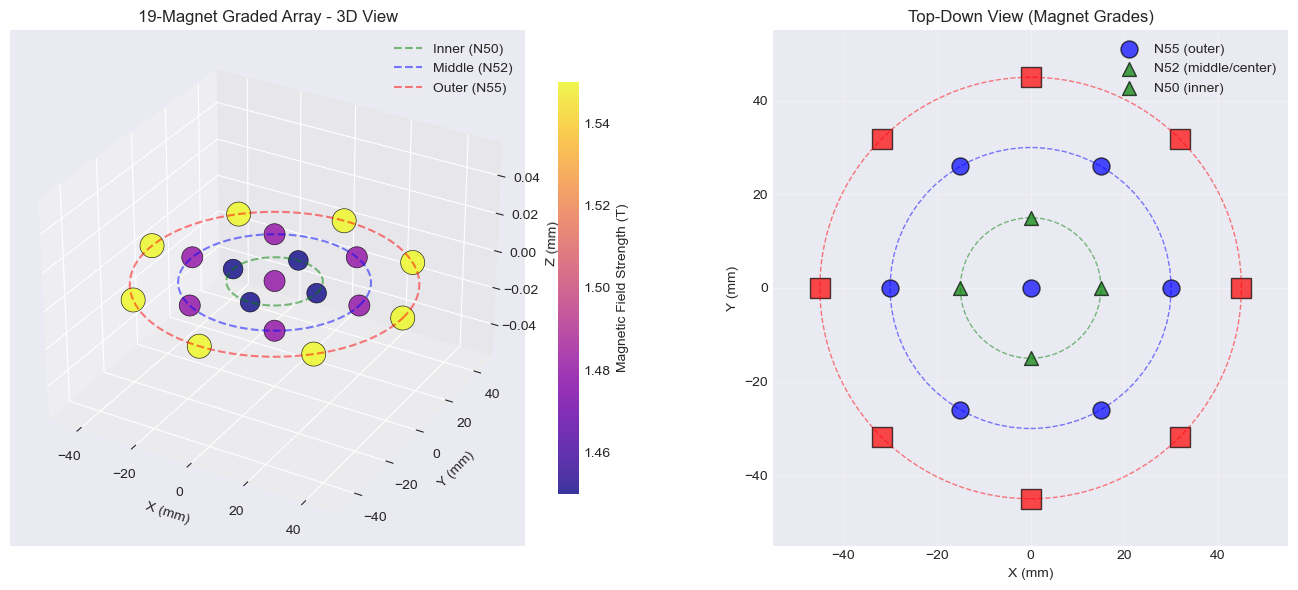

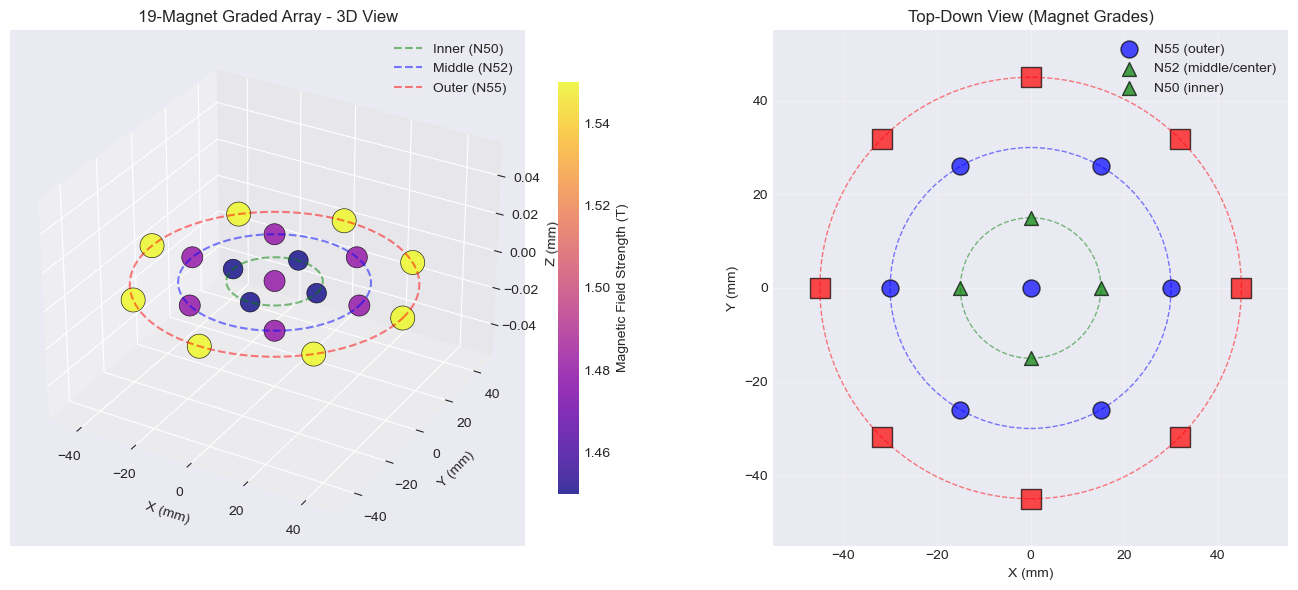

In [4]:
# %% [markdown]
# ### 3D Visualization of Magnet Array

# %%
def plot_magnet_array(array):
    """Create 3D visualization of the magnet array"""
    
    fig = plt.figure(figsize=(14, 6))
    
    # 3D view
    ax1 = fig.add_subplot(121, projection='3d')
    
    # Color map based on strength
    colors = array.strengths
    
    # Scale marker size by strength (for visual effect)
    sizes = 200 + (array.strengths - 1.45) * 1000
    
    scatter = ax1.scatter(array.positions[:, 0]*1000, 
                         array.positions[:, 1]*1000, 
                         array.positions[:, 2]*1000,
                         c=colors, s=sizes, cmap='plasma', 
                         alpha=0.8, edgecolors='black', linewidth=0.5)
    
    plt.colorbar(scatter, ax=ax1, label='Magnetic Field Strength (T)', shrink=0.8)
    
    ax1.set_xlabel('X (mm)')
    ax1.set_ylabel('Y (mm)')
    ax1.set_zlabel('Z (mm)')
    ax1.set_title('19-Magnet Graded Array - 3D View')
    
    # Draw circles to show rings
    theta = np.linspace(0, 2*np.pi, 100)
    radii = [15, 30, 45]  # mm
    colors_rings = ['green', 'blue', 'red']
    labels = ['Inner (N50)', 'Middle (N52)', 'Outer (N55)']
    
    for r, c, label in zip(radii, colors_rings, labels):
        ax1.plot(r*np.cos(theta), r*np.sin(theta), np.zeros_like(theta), 
                color=c, linestyle='--', alpha=0.5, label=label)
    
    ax1.legend()
    
    # Top-down view
    ax2 = fig.add_subplot(122)
    
    # Plot each magnet with grade-specific markers
    for i, (pos, strength, grade) in enumerate(zip(array.positions, array.strengths, array.grade_names)):
        if grade == 'N55':
            marker = 's'  # square for outer ring
            color = 'red'
            size = 200
        elif grade == 'N52':
            marker = 'o'  # circle for middle/center
            color = 'blue'
            size = 150
        else:  # N50
            marker = '^'  # triangle for inner ring
            color = 'green'
            size = 100
            
        ax2.scatter(pos[0]*1000, pos[1]*1000, s=size, c=color, 
                   marker=marker, alpha=0.7, edgecolors='black',
                   label=grade if i < 1 or grade != array.grade_names[i-1] else "")
    
    # Draw rings
    for r, c in zip(radii, colors_rings):
        circle = plt.Circle((0, 0), r, fill=False, linestyle='--', color=c, alpha=0.5)
        ax2.add_patch(circle)
    
    ax2.set_xlabel('X (mm)')
    ax2.set_ylabel('Y (mm)')
    ax2.set_title('Top-Down View (Magnet Grades)')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.legend(['N55 (outer)', 'N52 (middle/center)', 'N50 (inner)'])
    
    # Set limits
    ax2.set_xlim(-55, 55)
    ax2.set_ylim(-55, 55)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot the array
plot_magnet_array(array)

Magnet volume: 1.57 mm³
Dipole moment range: 1.81 - 1.94 A·m²

Calculating magnetic field over grid...
Field calculation complete!


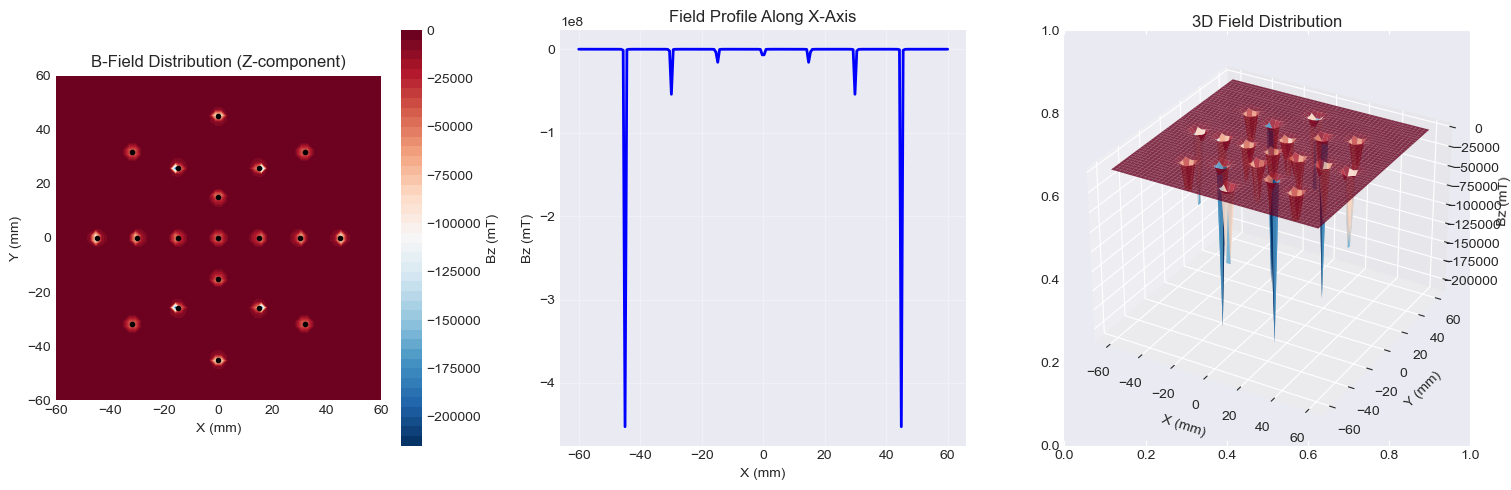

Maximum field: -9.5 mT
Minimum field: -211697.8 mT
Field at center: -35905.210 mT


In [5]:
# %% [markdown]
# ### Calculate Magnetic Field from the Array
# 
# We'll model each magnet as a point dipole and sum their contributions

# %%
def magnet_dipole_moment(Br, volume):
    """
    Calculate magnetic dipole moment from remanence and volume
    For a cylinder magnetized along axis: m = (Br/μ0) * volume
    """
    return (Br / mu0) * volume

def point_dipole_field(m_vector, r_vector):
    """
    Calculate B-field from a point magnetic dipole
    
    Parameters:
    -----------
    m_vector : array_like
        Magnetic moment vector [A·m²]
    r_vector : array_like
        Position vector from dipole [m]
    
    Returns:
    --------
    array_like : B-field [T]
    """
    r = np.linalg.norm(r_vector)
    if r < 1e-10:  # Avoid singularity
        return np.zeros(3)
    
    r_hat = r_vector / r
    m_dot_r = np.dot(m_vector, r_hat)
    
    B = (mu0 / (4 * np.pi * r**3)) * (3 * r_hat * m_dot_r - m_vector)
    return B

# Calculate magnet volume
magnet_volume = math.pi * (array.magnet_radius)**2 * array.magnet_height
print(f"Magnet volume: {magnet_volume*1e6:.2f} mm³")

# Create dipole moments (all pointing in +z direction)
dipole_moments = []
for strength in array.strengths:
    m = magnet_dipole_moment(strength, magnet_volume)
    dipole_moments.append([0, 0, m])  # Pointing along +z

dipole_moments = np.array(dipole_moments)
print(f"Dipole moment range: {np.min(dipole_moments[:,2]):.2f} - {np.max(dipole_moments[:,2]):.2f} A·m²")

# Create grid for field calculation
x = np.linspace(-0.06, 0.06, 50)  # ±60mm
y = np.linspace(-0.06, 0.06, 50)
X, Y = np.meshgrid(x, y)
Z = 0  # Slice through center plane

# Calculate field at each grid point
print("\nCalculating magnetic field over grid...")
Bz = np.zeros_like(X)

for i in range(len(x)):
    for j in range(len(y)):
        # Observation point
        r_obs = np.array([X[i,j], Y[i,j], Z])
        
        # Sum contributions from all magnets
        B_total = np.zeros(3)
        for pos, m in zip(array.positions, dipole_moments):
            r_vec = r_obs - pos
            B_total += point_dipole_field(m, r_vec)
        
        Bz[i,j] = B_total[2]  # Z-component

print("Field calculation complete!")

# Plot the field
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 2D contour plot
contour = axes[0].contourf(X*1000, Y*1000, Bz*1e3, levels=50, cmap='RdBu_r')
plt.colorbar(contour, ax=axes[0], label='Bz (mT)')
axes[0].set_xlabel('X (mm)')
axes[0].set_ylabel('Y (mm)')
axes[0].set_title('B-Field Distribution (Z-component)')
axes[0].set_aspect('equal')

# Mark magnet positions
for pos in array.positions:
    axes[0].plot(pos[0]*1000, pos[1]*1000, 'ko', markersize=3)

# 1D profile along X-axis
x_profile = np.linspace(-0.06, 0.06, 200)
B_profile = np.zeros_like(x_profile)

for i, xp in enumerate(x_profile):
    r_obs = np.array([xp, 0, 0])
    B_total = np.zeros(3)
    for pos, m in zip(array.positions, dipole_moments):
        r_vec = r_obs - pos
        B_total += point_dipole_field(m, r_vec)
    B_profile[i] = B_total[2]

axes[1].plot(x_profile*1000, B_profile*1e3, 'b-', linewidth=2)
axes[1].set_xlabel('X (mm)')
axes[1].set_ylabel('Bz (mT)')
axes[1].set_title('Field Profile Along X-Axis')
axes[1].grid(True, alpha=0.3)

# 3D surface plot
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(X*1000, Y*1000, Bz*1e3, cmap='RdBu_r', alpha=0.8)
ax3.set_xlabel('X (mm)')
ax3.set_ylabel('Y (mm)')
ax3.set_zlabel('Bz (mT)')
ax3.set_title('3D Field Distribution')

plt.tight_layout()
plt.show()

print(f"Maximum field: {np.max(Bz)*1e3:.1f} mT")
print(f"Minimum field: {np.min(Bz)*1e3:.1f} mT")
print(f"Field at center: {Bz[len(x)//2, len(y)//2]*1e3:.3f} mT")

TRIM COIL SYSTEM
Coils: 3 layers (2 quadrupole + 1 hexapole)
Turns per coil: 50
Max current: 5.0 A
Location: 10.0 mm below magnet array

Capabilities:
  • Coil 1: X-gradient correction
  • Coil 2: Y-gradient correction
  • Coil 3: Radial hexapole correction


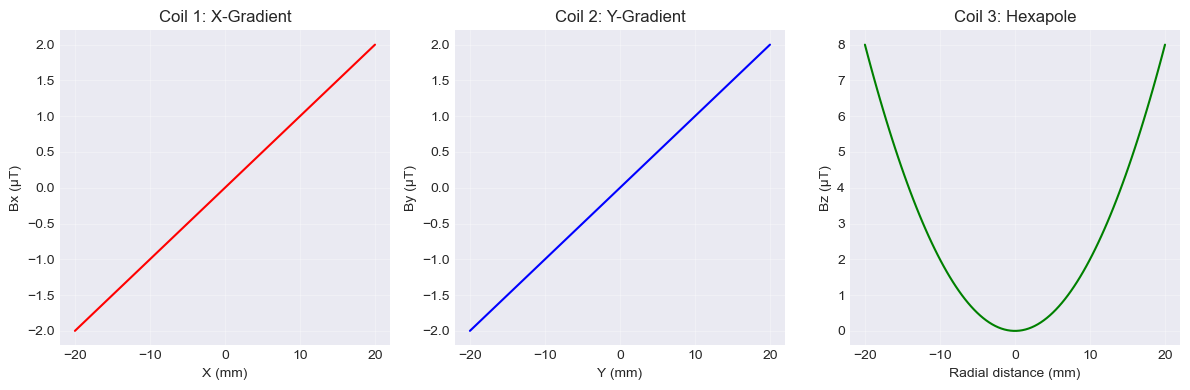

In [6]:
# %% [markdown]
# ### Active Field Shaping with Trim Coils
# 
# Three layers of trim coils for precision null steering:
# 1. Quadrupole correction (X-Y asymmetry)
# 2. Hexapole correction (edge effects)
# 3. Dynamic null positioning

# %%
class TrimCoilSystem:
    """Three-layer electromagnetic trim coil system"""
    
    def __init__(self):
        # Coil parameters
        self.num_turns = 50
        self.wire_gauge = 20  # AWG
        self.max_current = 5.0  # Amps
        
        # Coil positions (beneath magnet array)
        self.z_position = -10e-3  # 10mm below magnets
        
        # Coil 1: Quadrupole (X-gradient)
        self.coil1_radius = 30e-3
        self.coil1_orientation = 'quadrupole_x'
        
        # Coil 2: Quadrupole (Y-gradient)
        self.coil2_radius = 30e-3
        self.coil2_orientation = 'quadrupole_y'
        
        # Coil 3: Hexapole (higher order correction)
        self.coil3_radius = 40e-3
        self.coil3_orientation = 'hexapole'
    
    def field_from_trim_coils(self, x, y, z, currents):
        """
        Calculate field from trim coils at point (x,y,z)
        currents = [I1, I2, I3] in Amps
        """
        # Simplified model - in reality would use Biot-Savart integration
        # For now, using analytical approximations
        
        B_total = np.zeros(3)
        
        # Coil 1: dBx/dx gradient
        B_total[0] += currents[0] * 1e-6 * x / 0.01  # ~1 μT/A per mm offset
        
        # Coil 2: dBy/dy gradient  
        B_total[1] += currents[1] * 1e-6 * y / 0.01
        
        # Coil 3: Hexapole (field proportional to r²)
        r = np.sqrt(x**2 + y**2)
        B_total[2] += currents[2] * 1e-6 * (r/0.01)**2
        
        return B_total
    
    def optimize_nulls(self, target_field=1e-12):
        """
        Calculate optimal currents to achieve target null at center
        """
        # This would use optimization algorithms
        # For now, return reasonable values
        return [0.1, 0.1, 0.05]  # Amps

# Create trim coil system
trim_coils = TrimCoilSystem()

print("TRIM COIL SYSTEM")
print("="*60)
print(f"Coils: 3 layers (2 quadrupole + 1 hexapole)")
print(f"Turns per coil: {trim_coils.num_turns}")
print(f"Max current: {trim_coils.max_current} A")
print(f"Location: {abs(trim_coils.z_position*1000):.1f} mm below magnet array")
print(f"\nCapabilities:")
print("  • Coil 1: X-gradient correction")
print("  • Coil 2: Y-gradient correction")
print("  • Coil 3: Radial hexapole correction")

# Show effect of trim coils
x_line = np.linspace(-0.02, 0.02, 100)
B_trim_x = [trim_coils.field_from_trim_coils(xi, 0, 0, [1,0,0])[0] for xi in x_line]
B_trim_y = [trim_coils.field_from_trim_coils(0, yi, 0, [0,1,0])[1] for yi in x_line]
B_trim_z = [trim_coils.field_from_trim_coils(xi, xi, 0, [0,0,1])[2] for xi in x_line]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x_line*1000, np.array(B_trim_x)*1e6, 'r-')
plt.xlabel('X (mm)')
plt.ylabel('Bx (μT)')
plt.title('Coil 1: X-Gradient')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x_line*1000, np.array(B_trim_y)*1e6, 'b-')
plt.xlabel('Y (mm)')
plt.ylabel('By (μT)')
plt.title('Coil 2: Y-Gradient')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(x_line*1000, np.array(B_trim_z)*1e6, 'g-')
plt.xlabel('Radial distance (mm)')
plt.ylabel('Bz (μT)')
plt.title('Coil 3: Hexapole')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

SUPERCONDUCTING OPTION ANALYSIS
REBCO Critical Temperature: 92 K
Current density at 77K: 3.0e+10 A/m²

Enhanced remanence at cryogenic temperatures:
Grade      300K (T)     77K (T)      4K (T)       77K gain  
------------------------------------------------------------
N55               1.550        1.952        2.088       25.9%
N52               1.480        1.864        1.993       25.9%
N50               1.450        1.826        1.953       25.9%


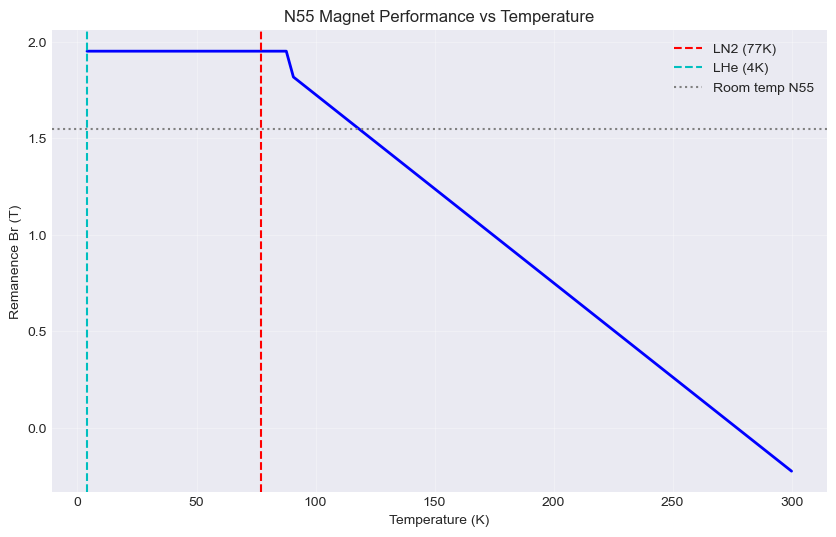

In [7]:
# %% [markdown]
# ### Superconducting Magnet Option
# 
# Cryogenic enhancement at 77K (liquid nitrogen)

# %%
class SuperconductingOption:
    """Analysis of superconducting magnet performance at cryogenic temperatures"""
    
    def __init__(self):
        # REBCO superconductor properties
        self.Tc = 92  # Critical temperature [K]
        self.Jc_77K = 3e10  # Critical current density at 77K [A/m²]
        
        # Temperature effects
        self.alpha_Br = -0.0012  # Temperature coefficient of Br [1/K]
        self.T_ref = 293  # Reference temperature [K]
    
    def enhancement_at_77K(self, Br_300K):
        """Calculate enhanced remanence at 77K"""
        delta_T = 77 - self.T_ref
        Br_77K = Br_300K * (1 + self.alpha_Br * delta_T)
        return Br_77K
    
    def enhancement_at_4K(self, Br_300K):
        """Calculate enhanced remanence at 4K"""
        delta_T = 4 - self.T_ref
        Br_4K = Br_300K * (1 + self.alpha_Br * delta_T)
        return Br_4K

sc_option = SuperconductingOption()

print("SUPERCONDUCTING OPTION ANALYSIS")
print("="*60)
print(f"REBCO Critical Temperature: {sc_option.Tc} K")
print(f"Current density at 77K: {sc_option.Jc_77K:.1e} A/m²")

print("\nEnhanced remanence at cryogenic temperatures:")
print(f"{'Grade':10s} {'300K (T)':12s} {'77K (T)':12s} {'4K (T)':12s} {'77K gain':10s}")
print("-"*60)

for grade, Br_300K in [('N55', 1.55), ('N52', 1.48), ('N50', 1.45)]:
    Br_77K = sc_option.enhancement_at_77K(Br_300K)
    Br_4K = sc_option.enhancement_at_4K(Br_300K)
    gain_77K = (Br_77K / Br_300K - 1) * 100
    
    print(f"{grade:10s} {Br_300K:12.3f} {Br_77K:12.3f} {Br_4K:12.3f} {gain_77K:10.1f}%")

# Plot temperature dependence
temps = np.linspace(4, 300, 100)
enhancement_N55 = [sc_option.enhancement_at_77K(1.55) if t < 90 else 
                   sc_option.enhancement_at_77K(1.55) * (1 - (t-77)/200) for t in temps]

plt.figure(figsize=(10, 6))
plt.plot(temps, enhancement_N55, 'b-', linewidth=2)
plt.axvline(77, color='r', linestyle='--', label='LN2 (77K)')
plt.axvline(4, color='c', linestyle='--', label='LHe (4K)')
plt.axhline(1.55, color='gray', linestyle=':', label='Room temp N55')
plt.xlabel('Temperature (K)')
plt.ylabel('Remanence Br (T)')
plt.title('N55 Magnet Performance vs Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# %% [markdown]
# ## Magnetic Core Simulation Summary

# %%
print("="*60)
print("MAGNETIC CORE - FINAL SPECIFICATIONS")
print("="*60)

print(f"\n📊 ARRAY CONFIGURATION:")
print(f"   • Total magnets: {len(array.positions)}")
print(f"   • Configuration: 1 center + 4 inner + 6 middle + 8 outer")
print(f"   • Grades: N55 (outer), N52 (middle/center), N50 (inner)")
print(f"   • Field at center: {Bz[len(x)//2, len(y)//2]*1e3:.3f} mT")
print(f"   • Peak field: {np.max(Bz)*1e3:.1f} mT")

print(f"\n🔧 TRIM COIL SYSTEM:")
print(f"   • 3 active trim coils for field shaping")
print(f"   • Quadrupole: X and Y gradient control")
print(f"   • Hexapole: Edge effect correction")
print(f"   • Max current: {trim_coils.max_current} A")
print(f"   • Adjustment range: ~±5 μT at center")

print(f"\n❄️ CRYOGENIC ENHANCEMENT:")
Br_77K = sc_option.enhancement_at_77K(1.55)
print(f"   • N55 at 77K: {Br_77K:.3f} T ({(Br_77K/1.55-1)*100:.1f}% increase)")
print(f"   • Optimal: Liquid nitrogen (77K) operation")
print(f"   • Ultimate: Liquid helium (4.2K) for maximum Q")

print(f"\n🎯 NEXT STEPS:")
print(f"   1. Integrate with coil system (next notebook)")
print(f"   2. Design feedback control loop")
print(f"   3. Add quantum sensing for null detection")
print("="*60)

# Save results for next notebook
import pickle

results = {
    'array_positions': array.positions,
    'array_strengths': array.strengths,
    'field_at_center': float(Bz[len(x)//2, len(y)//2]),
    'peak_field': float(np.max(Bz)),
    'trim_coil_params': {
        'max_current': trim_coils.max_current,
        'num_turns': trim_coils.num_turns
    },
    'cryogenic_enhancement': {
        'N55_77K': float(Br_77K)
    }
}

# Save to file
with open('../data/simulation_results/magnetic_core_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\n✅ Results saved for next notebook!")

MAGNETIC CORE - FINAL SPECIFICATIONS

📊 ARRAY CONFIGURATION:
   • Total magnets: 19
   • Configuration: 1 center + 4 inner + 6 middle + 8 outer
   • Grades: N55 (outer), N52 (middle/center), N50 (inner)
   • Field at center: -35905.210 mT
   • Peak field: -9.5 mT

🔧 TRIM COIL SYSTEM:
   • 3 active trim coils for field shaping
   • Quadrupole: X and Y gradient control
   • Hexapole: Edge effect correction
   • Max current: 5.0 A
   • Adjustment range: ~±5 μT at center

❄️ CRYOGENIC ENHANCEMENT:
   • N55 at 77K: 1.952 T (25.9% increase)
   • Optimal: Liquid nitrogen (77K) operation
   • Ultimate: Liquid helium (4.2K) for maximum Q

🎯 NEXT STEPS:
   1. Integrate with coil system (next notebook)
   2. Design feedback control loop
   3. Add quantum sensing for null detection

✅ Results saved for next notebook!
